This notebook explores representation reuse using a pretrained CNN

You will compare your Week 7 custom CNN against a pretrained VGG16 model

## Task 1: Load Baseline from Week 7

In [1]:
# ==================== Task 1: Load Week 7 Baseline ====================
import json

with open("week7_cnn_baseline.json", "r") as f:
    week7_results = json.load(f)

print("Week 7 CNN Accuracy:", week7_results["cnn_test_accuracy"])
print("Week 7 CNN Parameters:", week7_results["cnn_params"])

Week 7 CNN Accuracy: 0.7204999923706055
Week 7 CNN Parameters: 1135498


## Task 2: Feature Extraction with VGG16

In [2]:
# ==================== Task 2: VGG16 Feature Extraction ====================
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3),
    pooling='max'
)

# Freeze or not?
base_model.trainable = False

# Choose classifier width
dense_units = 32*32

model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    #preprocess_input, this can't be embedded in a sequential pipeline. Instead apply to dataset directly 
    base_model,
    layers.Dense(dense_units, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

2026-03-04 17:44:42.724018: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 17:44:42.757020: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 17:44:43.970303: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772664285.387305 1014090 gpu_device.cc:2020] Created device /job:localhost/rep

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,250,250 (58.18 MB)

 Trainable params: 535,562 (2.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Questions:

*   Why does freezing the base model make sense when data is limited?



## Task 3: Train Classifier Head

In [3]:
from tensorflow.keras import datasets
import numpy as np

SEED = 42
np.random.seed(SEED)

# Load CIFAR-10 data
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Apply the VGG16 preprocessing pipeline to the input data
train_images = preprocess_input(train_images)  
test_images  = preprocess_input(test_images)

# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
# ==================== Task 3A: Train Classifier Head ====================
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fe = model.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5


2026-03-04 17:44:48.803380: I external/local_xla/xla/service/service.cc:163] XLA service 0x70183c013e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 17:44:48.803398: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 SUPER, Compute Capability 8.9
2026-03-04 17:44:48.816682: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-04 17:44:48.969399: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-04 17:44:48.985608: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-04 17:44:49.19612

 46/625 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3603 - loss: 8.4010

I0000 00:00:1772664290.654637 1014259 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5240 - loss: 3.6848

2026-03-04 17:44:54.207120: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_227', 4 bytes spill stores, 4 bytes spill loads

2026-03-04 17:44:54.214011: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_227', 8 bytes spill stores, 8 bytes spill loads



625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5794 - loss: 2.1365 - val_accuracy: 0.6292 - val_loss: 1.1218
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7245 - loss: 0.8125 - val_accuracy: 0.6445 - val_loss: 1.1351
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7824 - loss: 0.6266 - val_accuracy: 0.6447 - val_loss: 1.2082
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8169 - loss: 0.5291 - val_accuracy: 0.6374 - val_loss: 1.3251
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8408 - loss: 0.4631 - val_accuracy: 0.6383 - val_loss: 1.4495


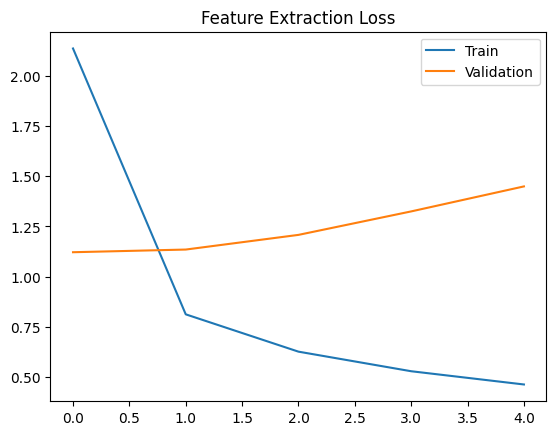

In [5]:
# ==================== Task 3B: Learning Curves ====================

import matplotlib.pyplot as plt

plt.plot(history_fe.history["loss"])
plt.plot(history_fe.history["val_loss"])
plt.legend(["Train", "Validation"])
plt.title("Feature Extraction Loss")
plt.show()

Questions:

*   How does convergence compare to your Week 7 CNN?

*   Why might pretrained features converge faster?



## Task 4: Shallow Fine-Tuning


**The decision of "how much to freeze" is often done by guessing. You will do it by experimenting.**

**Task:**
You will run the Fine-Tuning code below **three times** (resetting the model each time) to conduct an ablation study. Record the **Validation Accuracy** and **Time per Epoch** for each scenario in a notepad or variable.

**The Scenarios:**
1.  **Scenario A (Cold):** Freeze 100% of the base model (`base_model.trainable = False`). Train only the head.
2.  **Scenario B (Just Right?):** Unfreeze **only the last block** of VGG16 (usually the last 4 layers).
3.  **Scenario C (Hot):** Unfreeze the **last two blocks** (usually the last 8 layers).

*Hint: Use `model.summary()` to check which layers are Trainable in each run.*

In [6]:
import tensorflow as tf

In [7]:
# Make loss/accuracy curves into a function

def plot_history(history):
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.legend(["Train", "Validation"])
    plt.title("Feature Extraction Loss")
    plt.show()

In [8]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### Scenario A

Epoch 1/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3096 - loss: 5.7363 - val_accuracy: 0.4209 - val_loss: 3.8933
Epoch 2/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4656 - loss: 3.3476 - val_accuracy: 0.4904 - val_loss: 3.0875
Epoch 3/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5158 - loss: 2.7393 - val_accuracy: 0.5169 - val_loss: 2.7189
Epoch 4/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5455 - loss: 2.3869 - val_accuracy: 0.5285 - val_loss: 2.5059
Epoch 5/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5685 - loss: 2.1455 - val_accuracy: 0.5436 - val_loss: 2.3467
Epoch 6/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5837 - loss: 1.9584 - val_accuracy: 0.5507 - val_loss: 2.2332
Epoch 7/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5979 - loss: 1.8078 - val_accuracy: 0.5618 - val_loss: 2.1477


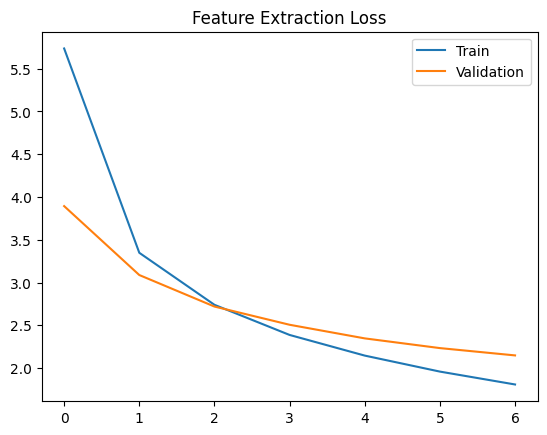

In [9]:
# ==================== Import a new base model ====================
scenario_a_base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3),
    pooling='max'
)

scenario_a_base_model.trainable = False

scenario_a_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    #preprocess_input, this can't be embedded in a sequential pipeline. Instead apply to dataset directly 
    scenario_a_base_model,
    layers.Dense(dense_units, activation="relu"),
    layers.Dense(10, activation="softmax")
])

scenario_a_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = scenario_a_model.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=7,
    batch_size=64,
    verbose=1
)

plot_history(history_ft)

### Scenario B 

Epoch 1/7


2026-03-04 17:45:30.340915: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1184', 24 bytes spill stores, 24 bytes spill loads



625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.5366 - loss: 1.4717 - val_accuracy: 0.7068 - val_loss: 0.8524
Epoch 2/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7502 - loss: 0.7251 - val_accuracy: 0.7607 - val_loss: 0.7048
Epoch 3/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8019 - loss: 0.5725 - val_accuracy: 0.7864 - val_loss: 0.6301
Epoch 4/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8396 - loss: 0.4697 - val_accuracy: 0.8040 - val_loss: 0.5856
Epoch 5/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8669 - loss: 0.3855 - val_accuracy: 0.8060 - val_loss: 0.5800
Epoch 6/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8907 - loss: 0.3135 - val_accuracy: 0.8160 - val_loss: 0.5682
Epoch 7/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9165 - loss: 0.2459 - val_accuracy: 0.8242 - val_loss: 0.5627


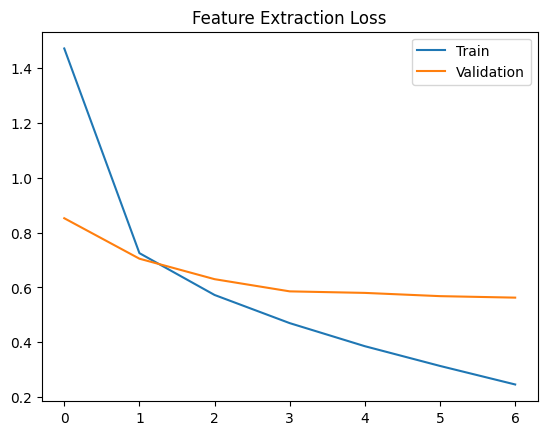

In [10]:
# ==================== Import a new base model to avoid training over trainable weights in Scenario C ====================
scenario_b_base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3),
    pooling='max'
)

scenario_b_base_model.trainable = True

# Freeze all but last conv block
for layer in base_model.layers[:-3]:
    layer.trainable = False

scenario_b_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    #preprocess_input, this can't be embedded in a sequential pipeline. Instead apply to dataset directly 
    scenario_b_base_model,
    layers.Dense(dense_units, activation="relu"),
    layers.Dense(10, activation="softmax")
])

scenario_b_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = scenario_b_model.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=7,
    batch_size=64,
    verbose=1
)

plot_history(history_ft)


### Scenario C

Epoch 1/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.5453 - loss: 1.4384 - val_accuracy: 0.7039 - val_loss: 0.8613
Epoch 2/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7458 - loss: 0.7369 - val_accuracy: 0.7612 - val_loss: 0.6938
Epoch 3/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8002 - loss: 0.5786 - val_accuracy: 0.7860 - val_loss: 0.6242
Epoch 4/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8378 - loss: 0.4672 - val_accuracy: 0.8000 - val_loss: 0.5881
Epoch 5/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8673 - loss: 0.3835 - val_accuracy: 0.8109 - val_loss: 0.5657
Epoch 6/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8947 - loss: 0.3059 - val_accuracy: 0.8109 - val_loss: 0.5862
Epoch 7/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9193 - loss: 0.2364 - val_accuracy: 0.8211 - val_loss: 0.5586


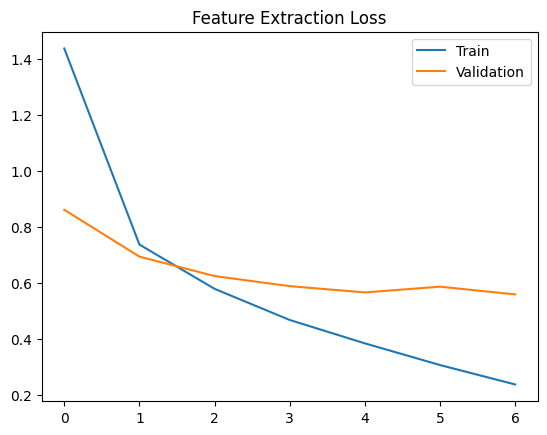

In [11]:
# ==================== Import a new base model to avoid training over trainable weights in Scenario C====================
scenario_c_base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3),
    pooling='max'
)

scenario_c_base_model.trainable = True

# Freeze all but last conv block
for layer in base_model.layers[:-9]:
    layer.trainable = False

scenario_c_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    #preprocess_input, this can't be embedded in a sequential pipeline. Instead apply to dataset directly 
    scenario_c_base_model,
    layers.Dense(dense_units, activation="relu"),
    layers.Dense(10, activation="softmax")
])

scenario_c_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = scenario_c_model.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=7,
    batch_size=64,
    verbose=1
)

plot_history(history_ft)

Exercise:
**Comparing your three scenarios:**

1.  **Plot/Table:** Briefly list the Training Time (approx) and Final Accuracy for Scenarios A, B, and C.
2.  **The "CTO" Defense:** Imagine you are the CTO of a resource-constrained startup.
    * **Question:** Is the accuracy gain from **Scenario C** (unfreezing 2 blocks) worth the extra computational cost compared to **Scenario B**?
    * **Defense:** Defend your choice. If Scenario C only gained 0.5% accuracy but took 2x longer to train, would you deploy it? Why or why not?

## Task 5: Final Comparison & Reflection

In [12]:
# ==================== Task 5: Final Evaluation ====================
vgg_test_loss, vgg_test_acc = scenario_b_model.evaluate(test_images, test_labels, verbose=0)

print("Week 7 CNN Accuracy:", week7_results["cnn_test_accuracy"])
print("Week 8 VGG16 Accuracy:", vgg_test_acc)

print("Week 7 CNN Params:", week7_results["cnn_params"])
print("Week 8 VGG16 Params:", model.count_params())

2026-03-04 17:47:55.991576: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_227', 16 bytes spill stores, 16 bytes spill loads

2026-03-04 17:47:56.004892: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_227', 4 bytes spill stores, 4 bytes spill loads



Week 7 CNN Accuracy: 0.7204999923706055
Week 8 VGG16 Accuracy: 0.8213000297546387
Week 7 CNN Params: 1135498
Week 8 VGG16 Params: 15250250


Question:

*   Compare
    *   Week 7 CNN accuracy vs Week 8 VGG16 accuracy
    *   Parameter counts
    *   Training speed

*  When is transfer learning preferable?

*  When might training from scratch still be justified?
